# Chapter 1. Elementary Differential Geometry

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter I, printed pages 2-97 (approximately PDF pages 29-124).

This notebook is a standalone course module for the chapter. It does not reproduce the textbook's prose or exercises; instead it rebuilds the chapter's constructions through original explanations, visual models, symbolic checks, and small computational experiments. The chapter begins with smooth manifolds as spaces glued from compatible charts, then turns tangent vectors into derivations, differential forms into computable alternating objects, mappings into differentials and pullbacks, affine connections into rules for differentiating vector fields, and Riemannian curvature into a measurable departure from Euclidean geometry.

The organizing question is: what local data lets geometry be transported, compared, and measured without choosing coordinates permanently? Each section below gives a computational witness for one step of that answer.


## Visual Storyboard, Library Routing, and Coverage Plan

The source span has a long arc, so the visual plan is deliberately structural rather than decorative. The notebook uses small models to keep the chapter's main dependencies visible.

- Smooth structure and partitions of unity: overlapping local functions are normalized into a partition on a covered interval, mirroring the chapter's move from local charts to global constructions.
- Tensor fields and forms: derivations, exterior differentiation, and pullback are checked symbolically, so coordinate formulas become testable algebra.
- Mappings and regularity: a grid deformation displays the differential, pushforward of tangent arrows, and the Jacobian determinant behind pullbacks of area forms.
- Affine connections and the exponential map: a geodesic fan on the sphere makes normal coordinates, radial geodesics, and the exponential map visible.
- Structural equations and curvature: geodesic disk area and Jacobi field factors compare positive, zero, and negative curvature.
- Negative curvature and totally geodesic submanifolds: length expansion, triangle behavior, fixed-point intuition, and normal decompositions are linked to concrete sphere/hyperbolic/flat computations.
- Appendix and exercise themes: paracompactness, constant rank, Lie derivative/interior product, curvature by holonomy, surface connections, and the hyperbolic disk are routed through the coverage ledger; the executable labs focus on the mechanisms that the chapter reuses later.

**Library Routing.** NumPy and Pandas handle numerical experiments and coverage tables; Matplotlib creates the diagrams; SymPy checks exterior derivative and pullback identities; the local artifact helpers save every figure, table, and sanity report under the book-local `artifacts/` subtree.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - activates 3D projection
import numpy as np
import sympy as sp

_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the Helgason book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (  # noqa: E402
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-01-elementary-differential-geometry"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

artifact_paths: list[Path] = []
chapter_checks: dict[str, bool | float | str] = {}

def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)


In [2]:
storyboard = [
    {
        "source_sections": "1. Manifolds",
        "notebook_witness": "bump functions and normalized partition of unity on an overlapping cover",
        "artifact": "figures/partition_of_unity_cover.png",
        "coverage_role": "shows how local smooth data can be patched into global constructions",
    },
    {
        "source_sections": "2. Tensor fields",
        "notebook_witness": "symbolic derivation and exterior derivative checks",
        "artifact": "checks/forms_pullback_symbolic_checks.json",
        "coverage_role": "turns tangent vectors, forms, and d^2=0 into verifiable algebra",
    },
    {
        "source_sections": "3. Mappings",
        "notebook_witness": "grid deformation, tangent arrow pushforward, Jacobian determinant heat",
        "artifact": "figures/mapping_differential_pullback.png",
        "coverage_role": "connects differentials, regularity, pushforward, and pullback",
    },
    {
        "source_sections": "4-8. Affine connections, parallelism, exponential map, structural equations",
        "notebook_witness": "sphere exponential fan and connection-to-curvature dependency table",
        "artifact": "figures/sphere_exponential_geodesic_fan.png; figures/parallel_transport_connection_lab.png; checks/cartan_structural_equations_checks.json",
        "coverage_role": "makes normal coordinates, parallel transport, connection coefficients, torsion, and curvature visible",
    },
    {
        "source_sections": "9-12. Riemannian connection, geodesic distance, isometries, sectional curvature",
        "notebook_witness": "area deficit and Jacobi factor comparisons for constant curvature models",
        "artifact": "figures/curvature_area_and_jacobi_factors.png",
        "coverage_role": "uses geodesic disk measurements to expose sectional curvature",
    },
    {
        "source_sections": "13. Negative curvature",
        "notebook_witness": "hyperbolic length expansion compared with flat and spherical models",
        "artifact": "figures/curvature_sign_lab.png",
        "coverage_role": "models the length-expanding behavior of d Exp in nonpositive curvature",
    },
    {
        "source_sections": "14. Totally geodesic submanifolds",
        "notebook_witness": "equator vs latitude residual on the sphere",
        "artifact": "figures/totally_geodesic_equator_vs_latitude.png",
        "coverage_role": "distinguishes intrinsic geodesics from submanifolds that remain geodesic in the ambient space",
    },
    {
        "source_sections": "15. Appendix and exercise groups A-G",
        "notebook_witness": "coverage table plus symbolic/numerical hooks for rank, Lie derivative, holonomy, surfaces, and hyperbolic disk",
        "artifact": "tables/chapter_01_coverage_map.csv",
        "coverage_role": "tracks every source section and major exercise theme to a notebook explanation or computation",
    },
]

coverage_rows = [
    {"source_part": "1 Manifolds", "captured_as": "smooth atlases, compatibility, bump functions, partitions of unity", "notebook_section": "Smooth structure and partitions"},
    {"source_part": "2 Tensor fields", "captured_as": "tangent derivations, tensor/form grammar, exterior derivative", "notebook_section": "Forms and pullbacks"},
    {"source_part": "3 Mappings", "captured_as": "differential, regular maps, submanifold local form, pushforward, pullback", "notebook_section": "Mapping differential"},
    {"source_part": "4 Affine connections", "captured_as": "covariant derivative and connection coefficients as rules for differentiating fields", "notebook_section": "Connections to exponential maps"},
    {"source_part": "5 Parallelism", "captured_as": "parallel transport as connection-controlled comparison along curves", "notebook_section": "Connections to exponential maps"},
    {"source_part": "6 Exponential mapping", "captured_as": "geodesic fan from tangent vectors and normal coordinate intuition", "notebook_section": "Sphere exponential map"},
    {"source_part": "7 Normal and convex neighborhoods", "captured_as": "local uniqueness/minimizing behavior of short geodesics", "notebook_section": "Sphere exponential map"},
    {"source_part": "8 Structural equations", "captured_as": "torsion/curvature as defects measured by moving frames", "notebook_section": "Curvature measurements"},
    {"source_part": "9 Riemannian connection", "captured_as": "metric-compatible torsion-free connection as the canonical differentiator", "notebook_section": "Curvature measurements"},
    {"source_part": "10 Geodesics and distance", "captured_as": "local minimizing geodesics and radial distance comparisons", "notebook_section": "Curvature measurements"},
    {"source_part": "11 Isometries", "captured_as": "isometries preserve geodesics, curvature, and metric measurements", "notebook_section": "Curvature measurements"},
    {"source_part": "12 Sectional curvature", "captured_as": "area deficit and Jacobi factors for 2-planes", "notebook_section": "Curvature measurements"},
    {"source_part": "13 Negative curvature", "captured_as": "length expansion of d Exp, triangle angle deficit, fixed-point intuition", "notebook_section": "Negative curvature lab"},
    {"source_part": "14 Totally geodesic submanifolds", "captured_as": "ambient geodesic residual for equator versus latitude", "notebook_section": "Totally geodesic check"},
    {"source_part": "15 Appendix", "captured_as": "paracompactness, shrinking covers, separability, constant-rank normal form", "notebook_section": "Coverage map and takeaways"},
    {"source_part": "Exercises A-G", "captured_as": "selected executable witnesses for Lie derivative/interior product, affine connection curvature, surface-style parallel transport, and hyperbolic constant-curvature behavior; remaining proof exercises are listed as further work", "notebook_section": "Exterior algebra, connection lab, curvature lab, and coverage ledger"},
]

storyboard_path = record(save_json(storyboard, CHECKS / "chapter_01_visual_storyboard.json"))
coverage_path = record(save_csv(coverage_rows, TABLES / "chapter_01_coverage_map.csv"))
print(json.dumps({"storyboard_items": len(storyboard), "coverage_rows": len(coverage_rows), "storyboard": rel(storyboard_path), "coverage": rel(coverage_path)}, indent=2))
display_artifact(coverage_path)


{
  "storyboard_items": 8,
  "coverage_rows": 16,
  "storyboard": "artifacts/chapter-01-elementary-differential-geometry/checks/chapter_01_visual_storyboard.json",
  "coverage": "artifacts/chapter-01-elementary-differential-geometry/tables/chapter_01_coverage_map.csv"
}


[chapter_01_coverage_map.csv](artifacts/chapter-01-elementary-differential-geometry/tables/chapter_01_coverage_map.csv)

### Exterior Algebra, Contraction, and Lie Derivative Check

The chapter's tensor-field section is more than a notation list: it sets up the algebra that later lets curvature and invariant forms be written without choosing permanent coordinates. The next check models a small piece of that algebra on `R^2`. It verifies the contraction rule for a wedge product and Cartan's formula for the Lie derivative of a 1-form:

`L_X alpha = i_X d alpha + d(i_X alpha)`.

This is also the notebook's executable bridge to the exercise themes on Lie derivative and interior product.


In [3]:
x, y = sp.symbols("x y")
a = x * y
b = x**2 + y
c = sp.sin(x)
d = x + y**2
alpha = sp.Matrix([a, b])
beta = sp.Matrix([c, d])
X_field = sp.Matrix([1 + x * y, x - y])

def wedge_1_1(form_a: sp.Matrix, form_b: sp.Matrix) -> sp.Expr:
    return sp.simplify(form_a[0] * form_b[1] - form_a[1] * form_b[0])

def interior_two_form(vector: sp.Matrix, coeff: sp.Expr) -> sp.Matrix:
    # i_X(q dx wedge dy) = q(X^x dy - X^y dx), represented as dx,dy coefficients.
    return sp.Matrix([sp.simplify(-coeff * vector[1]), sp.simplify(coeff * vector[0])])

def exterior_derivative_one_form(form: sp.Matrix) -> sp.Expr:
    return sp.simplify(sp.diff(form[1], x) - sp.diff(form[0], y))

def exterior_derivative_zero_form(expr: sp.Expr) -> sp.Matrix:
    return sp.Matrix([sp.diff(expr, x), sp.diff(expr, y)])

def lie_derivative_one_form(vector: sp.Matrix, form: sp.Matrix) -> sp.Matrix:
    coords2 = [x, y]
    components = []
    for i, coord in enumerate(coords2):
        transport = sum(vector[j] * sp.diff(form[i], coords2[j]) for j in range(2))
        correction = sum(form[j] * sp.diff(vector[j], coord) for j in range(2))
        components.append(sp.simplify(transport + correction))
    return sp.Matrix(components)

wedge_coeff = wedge_1_1(alpha, beta)
lhs_contraction = interior_two_form(X_field, wedge_coeff)
rhs_contraction = sp.simplify((alpha.dot(X_field)) * beta - (beta.dot(X_field)) * alpha)
contraction_residual = sp.simplify(lhs_contraction - rhs_contraction)

d_alpha = exterior_derivative_one_form(alpha)
cartan_rhs = sp.simplify(interior_two_form(X_field, d_alpha) + exterior_derivative_zero_form(alpha.dot(X_field)))
cartan_lhs = lie_derivative_one_form(X_field, alpha)
cartan_residual = sp.simplify(cartan_lhs - cartan_rhs)

exterior_rows = [
    {"operation": "alpha wedge beta", "result": str(wedge_coeff), "check": "alternating 2-form coefficient"},
    {"operation": "i_X(alpha wedge beta)", "result": str(list(lhs_contraction)), "check": "equals alpha(X) beta - beta(X) alpha"},
    {"operation": "L_X alpha", "result": str(list(cartan_lhs)), "check": "equals i_X d alpha + d(i_X alpha)"},
]
exterior_table = record(save_csv(exterior_rows, TABLES / "exterior_algebra_operations.csv"))
exterior_report = record(save_json({
    "wedge_coefficient": str(wedge_coeff),
    "contraction_residual": [str(sp.simplify(term)) for term in contraction_residual],
    "cartan_formula_residual": [str(sp.simplify(term)) for term in cartan_residual],
    "checks": {
        "contraction_rule_holds": bool(all(sp.simplify(term) == 0 for term in contraction_residual)),
        "cartan_formula_holds_for_model_one_form": bool(all(sp.simplify(term) == 0 for term in cartan_residual)),
    },
}, CHECKS / "exterior_algebra_lie_derivative_checks.json"))
chapter_checks["exterior_contraction_rule_holds"] = bool(all(sp.simplify(term) == 0 for term in contraction_residual))
chapter_checks["cartan_lie_derivative_formula_holds"] = bool(all(sp.simplify(term) == 0 for term in cartan_residual))
print(json.dumps({"table": rel(exterior_table), "checks": rel(exterior_report)}, indent=2))
display_artifact(exterior_table)


{
  "table": "artifacts/chapter-01-elementary-differential-geometry/tables/exterior_algebra_operations.csv",
  "checks": "artifacts/chapter-01-elementary-differential-geometry/checks/exterior_algebra_lie_derivative_checks.json"
}


[exterior_algebra_operations.csv](artifacts/chapter-01-elementary-differential-geometry/tables/exterior_algebra_operations.csv)

## 1. Smooth Structure and Partitions of Unity

The chapter's manifold definition is not just a topological wrapper around coordinates. A differentiable structure says that whenever two charts overlap, their coordinate changes are smooth, and the smooth functions are the coordinate-independent objects detected by all charts. Paracompactness and countability hypotheses then let the chapter use partitions of unity: locally supported smooth functions whose sum is one on the region of interest.

The plot below is a one-dimensional model of that mechanism. Three compactly supported bump functions form an overlapping cover. Normalizing them creates weights that are nonnegative, locally supported, and sum to one wherever the cover is active. The exact interval is only a model, but the logic is the same one used later to build Riemannian metrics and global tensor fields from local data.


{
  "max_partition_error": 2.220446049250313e-16,
  "table": "artifacts/chapter-01-elementary-differential-geometry/tables/partition_of_unity_samples.csv",
  "figure": "artifacts/chapter-01-elementary-differential-geometry/figures/partition_of_unity_cover.png"
}


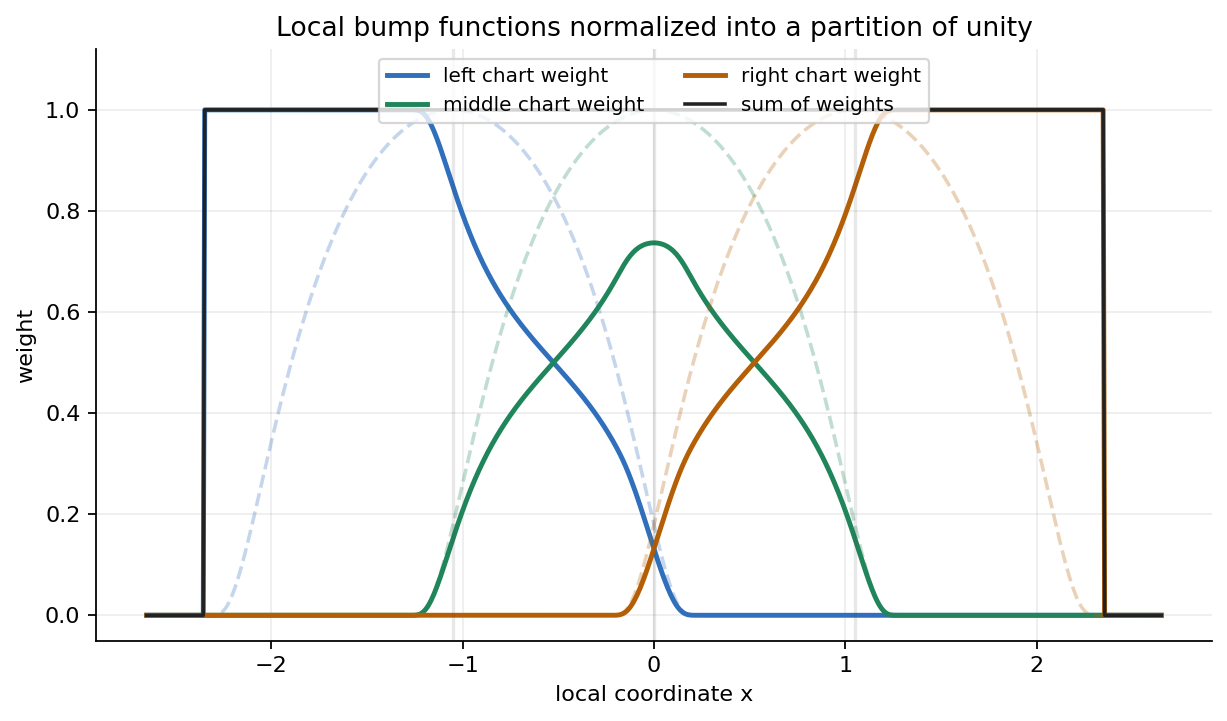

In [4]:
def bump(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    out = np.zeros_like(z)
    mask = np.abs(z) < 1.0
    out[mask] = np.exp(-1.0 / (1.0 - z[mask] ** 2))
    return out

x_grid = np.linspace(-2.65, 2.65, 700)
centers = np.array([-1.05, 0.0, 1.05])
radius = 1.32
raw = np.vstack([bump((x_grid - c) / radius) for c in centers])
denominator = raw.sum(axis=0)
covered = denominator > 1e-14
weights = np.zeros_like(raw)
weights[:, covered] = raw[:, covered] / denominator[covered]
partition_sum = weights.sum(axis=0)

partition_rows = []
for idx in np.linspace(0, len(x_grid) - 1, 31, dtype=int):
    partition_rows.append({
        "x": float(x_grid[idx]),
        "w_left": float(weights[0, idx]),
        "w_middle": float(weights[1, idx]),
        "w_right": float(weights[2, idx]),
        "sum": float(partition_sum[idx]),
    })
partition_table = record(save_csv(partition_rows, TABLES / "partition_of_unity_samples.csv"))

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ["#2f6fbb", "#20855a", "#b45f06"]
labels = ["left chart weight", "middle chart weight", "right chart weight"]
for i, (color, label) in enumerate(zip(colors, labels)):
    ax.plot(x_grid, raw[i] / max(raw[i].max(), 1e-12), color=color, alpha=0.28, linestyle="--", linewidth=1.6)
    ax.plot(x_grid, weights[i], color=color, linewidth=2.2, label=label)
ax.plot(x_grid, partition_sum, color="#222222", linewidth=1.6, label="sum of weights")
for c in centers:
    ax.axvline(c, color="#444444", alpha=0.12)
ax.set_title("Local bump functions normalized into a partition of unity")
ax.set_xlabel("local coordinate x")
ax.set_ylabel("weight")
ax.set_ylim(-0.05, 1.12)
ax.legend(loc="upper center", ncol=2, fontsize=9)
partition_figure = record(save_matplotlib(fig, FIGURES / "partition_of_unity_cover.png"))
plt.close(fig)

partition_error = float(np.max(np.abs(partition_sum[covered] - 1.0)))
chapter_checks["partition_weights_nonnegative"] = bool(np.all(weights >= -1e-12))
chapter_checks["partition_sum_close_to_one"] = bool(partition_error < 1e-12)
chapter_checks["partition_has_local_support"] = bool(np.all(raw[:, 0] < 1e-10) and np.all(raw[:, -1] < 1e-10))
print(json.dumps({"max_partition_error": partition_error, "table": rel(partition_table), "figure": rel(partition_figure)}, indent=2))
display_artifact(partition_figure)


## 2. Tangent Vectors, Forms, and Pullbacks

Helgason defines tangent vectors by how they differentiate smooth functions. That viewpoint is powerful because it makes tensors and forms coordinate-independent while still computable in coordinates. A vector field is a derivation, a 1-form eats vector fields, and the exterior derivative turns local coefficient functions into antisymmetric information.

The symbolic check below keeps three chapter facts honest.

- Applying the exterior derivative twice to a function gives zero.
- Pulling back an area form through a map multiplies it by the Jacobian determinant.
- A vector field bracket can be computed from the derivation rule, so it measures the failure of two infinitesimal flows to commute.


In [5]:
x, y, u, v = sp.symbols("x y u v")

f = x**2 * y + sp.sin(y)
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
d2f_area_coeff = sp.simplify(sp.diff(df_dy, x) - sp.diff(df_dx, y))

Fx = u + sp.Rational(1, 4) * u * v
Fy = v + sp.Rational(1, 5) * u**2
J = sp.Matrix([[sp.diff(Fx, u), sp.diff(Fx, v)], [sp.diff(Fy, u), sp.diff(Fy, v)]])
detJ = sp.simplify(J.det())
pullback_area_coeff = sp.simplify(sp.diff(Fx, u) * sp.diff(Fy, v) - sp.diff(Fx, v) * sp.diff(Fy, u))

X = sp.Matrix([1 + x, y])
Y = sp.Matrix([x * y, 1 - y])
coords = sp.Matrix([x, y])
bracket_XY = sp.simplify(Y.jacobian(coords) * X - X.jacobian(coords) * Y)
probe = x**2 + y**2
bracket_on_probe = sp.simplify(bracket_XY[0] * sp.diff(probe, x) + bracket_XY[1] * sp.diff(probe, y))

forms_report = {
    "d2_on_function_residual": str(d2f_area_coeff),
    "pullback_area_coefficient": str(pullback_area_coeff),
    "jacobian_determinant": str(detJ),
    "pullback_matches_jacobian": bool(sp.simplify(pullback_area_coeff - detJ) == 0),
    "bracket_vector_field": [str(sp.simplify(term)) for term in bracket_XY],
    "bracket_applied_to_probe_function": str(bracket_on_probe),
}
forms_path = record(save_json(forms_report, CHECKS / "forms_pullback_symbolic_checks.json"))
chapter_checks["d_squared_zero_on_function"] = bool(d2f_area_coeff == 0)
chapter_checks["pullback_area_matches_jacobian"] = forms_report["pullback_matches_jacobian"]
print(json.dumps(forms_report, indent=2))
display_artifact(forms_path)


{
  "d2_on_function_residual": "0",
  "pullback_area_coefficient": "-u**2/10 + v/4 + 1",
  "jacobian_determinant": "-u**2/10 + v/4 + 1",
  "pullback_matches_jacobian": true,
  "bracket_vector_field": [
    "y*(x + 1)",
    "-1"
  ],
  "bracket_applied_to_probe_function": "2*y*(x*(x + 1) - 1)"
}


`forms_pullback_symbolic_checks.json`

## 3. Mappings, Differentials, and Regularity

A smooth map is locally visible through its differential. When the rank of that differential is stable, the chapter's constant-rank theorem gives a normal form: locally the map looks like projection onto the active coordinates. This is the local engine behind submanifolds, graph embeddings, and level sets.

The next diagram uses the same nonlinear map as the symbolic pullback check. On the left is a coordinate grid in the source. On the right is its image, with the pushed-forward tangent arrows at one point. The color encodes the Jacobian determinant; staying positive on this square means the map is locally regular there and preserves orientation.


{
  "figure": "artifacts/chapter-01-elementary-differential-geometry/figures/mapping_differential_pullback.png",
  "summary": "artifacts/chapter-01-elementary-differential-geometry/tables/mapping_differential_summary.csv",
  "determinant_range": [
    0.65,
    1.2499873753313975
  ]
}


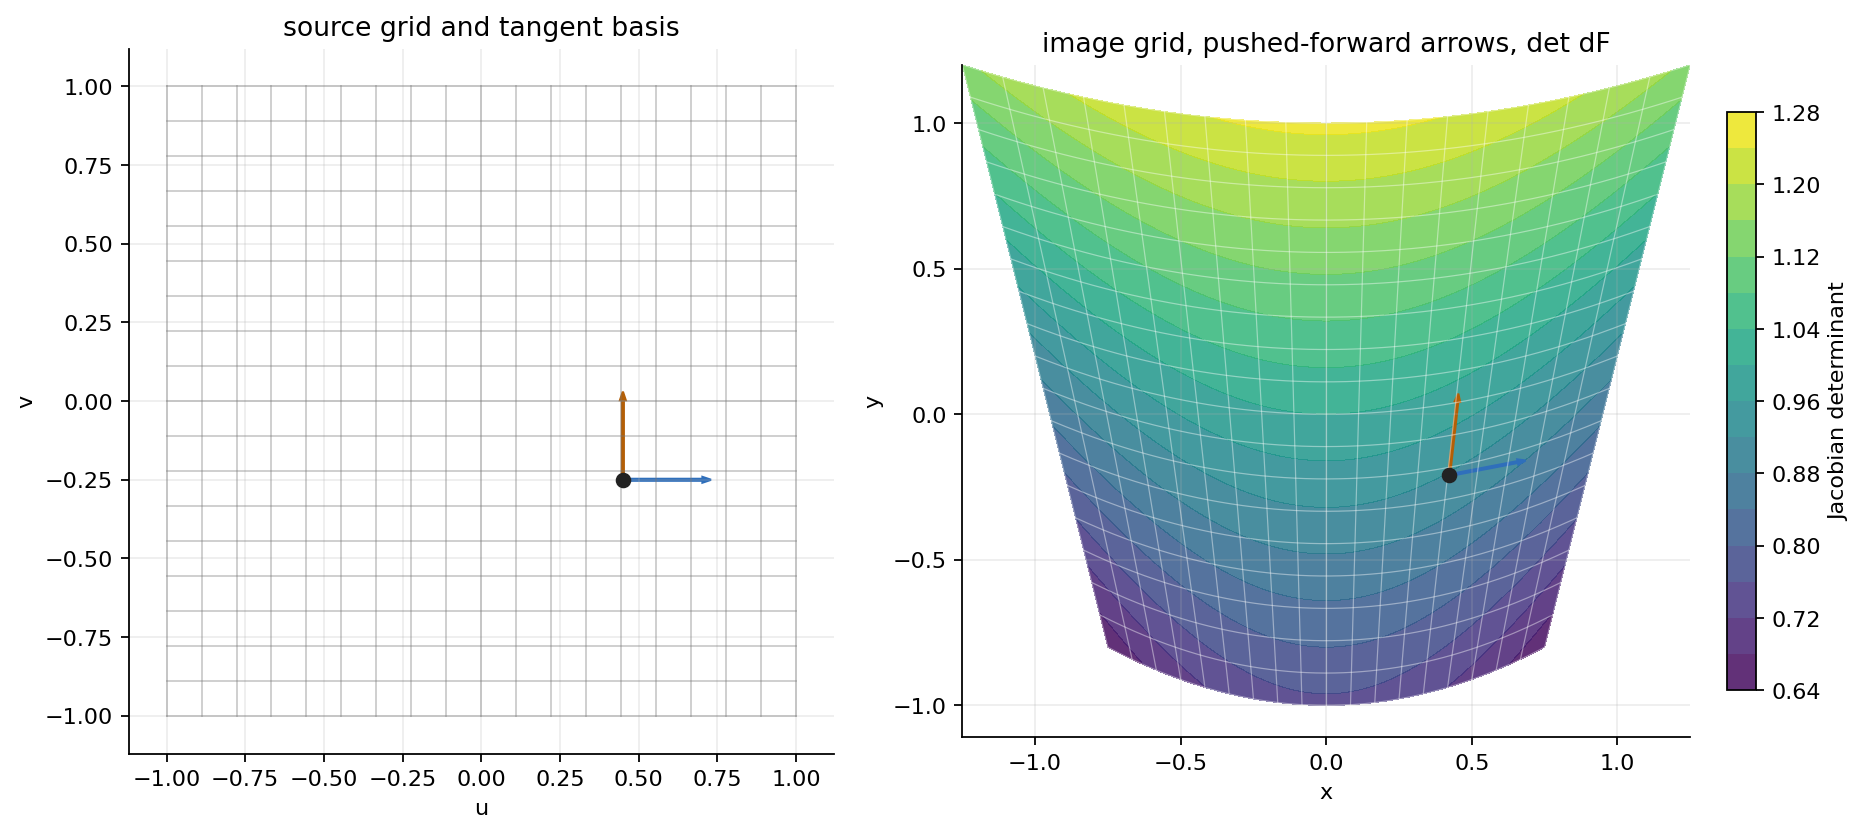

In [6]:
def F_numeric(U: np.ndarray, V: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return U + 0.25 * U * V, V + 0.2 * U**2

def J_numeric(u0: float, v0: float) -> np.ndarray:
    return np.array([[1.0 + 0.25 * v0, 0.25 * u0], [0.4 * u0, 1.0]], dtype=float)

grid = np.linspace(-1.0, 1.0, 19)
U, V = np.meshgrid(np.linspace(-1.0, 1.0, 90), np.linspace(-1.0, 1.0, 90))
Jdet = (1.0 + 0.25 * V) - 0.1 * U**2

p0 = np.array([0.45, -0.25])
Fp0 = np.array(F_numeric(np.array([p0[0]]), np.array([p0[1]]))).reshape(2)
Jp0 = J_numeric(float(p0[0]), float(p0[1]))
source_arrows = [np.array([0.28, 0.0]), np.array([0.0, 0.28])]
image_arrows = [Jp0 @ vec for vec in source_arrows]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.1), constrained_layout=True)
ax0, ax1 = axes
for t in grid:
    ax0.plot(grid, np.full_like(grid, t), color="#777777", alpha=0.38, linewidth=0.8)
    ax0.plot(np.full_like(grid, t), grid, color="#777777", alpha=0.38, linewidth=0.8)
ax0.scatter([p0[0]], [p0[1]], color="#222222", zorder=5)
for vec, color in zip(source_arrows, ["#2f6fbb", "#b45f06"]):
    ax0.arrow(p0[0], p0[1], vec[0], vec[1], color=color, width=0.006, length_includes_head=True)
ax0.set_title("source grid and tangent basis")
ax0.set_aspect("equal")
ax0.set_xlim(-1.12, 1.12)
ax0.set_ylim(-1.12, 1.12)
ax0.set_xlabel("u")
ax0.set_ylabel("v")

contour = ax1.contourf(*F_numeric(U, V), Jdet, levels=18, cmap="viridis", alpha=0.85)
for t in grid:
    line = np.linspace(-1.0, 1.0, 200)
    ax1.plot(*F_numeric(line, np.full_like(line, t)), color="white", alpha=0.42, linewidth=0.55)
    ax1.plot(*F_numeric(np.full_like(line, t), line), color="white", alpha=0.42, linewidth=0.55)
ax1.scatter([Fp0[0]], [Fp0[1]], color="#222222", zorder=5)
for vec, color in zip(image_arrows, ["#2f6fbb", "#b45f06"]):
    ax1.arrow(Fp0[0], Fp0[1], vec[0], vec[1], color=color, width=0.006, length_includes_head=True)
ax1.set_title("image grid, pushed-forward arrows, det dF")
ax1.set_aspect("equal")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
fig.colorbar(contour, ax=ax1, shrink=0.82, label="Jacobian determinant")

mapping_figure = record(save_matplotlib(fig, FIGURES / "mapping_differential_pullback.png"))
plt.close(fig)

mapping_rows = [{
    "point_u": float(p0[0]),
    "point_v": float(p0[1]),
    "det_dF_at_point": float(np.linalg.det(Jp0)),
    "det_dF_min_on_square": float(Jdet.min()),
    "det_dF_max_on_square": float(Jdet.max()),
    "regular_on_square": bool(Jdet.min() > 0),
}]
mapping_table = record(save_csv(mapping_rows, TABLES / "mapping_differential_summary.csv"))
chapter_checks["mapping_regular_on_model_square"] = bool(Jdet.min() > 0)
print(json.dumps({"figure": rel(mapping_figure), "summary": rel(mapping_table), "determinant_range": [float(Jdet.min()), float(Jdet.max())]}, indent=2))
display_artifact(mapping_figure)


## 4. Affine Connections, Parallelism, and the Exponential Map

A connection answers a question coordinates alone cannot answer: how should a vector field be differentiated along another vector field? Once a connection is chosen, it defines parallel transport, geodesics, curvature, and torsion. In the Riemannian case, the Levi-Civita connection is the unique connection that is torsion-free and compatible with the metric.

The exponential map packages geodesic initial-value problems. Starting at a point `p`, a tangent vector `v` is sent to the endpoint at time one of the geodesic with initial velocity `v`. Around the zero vector this gives normal coordinates; within a convex normal neighborhood, short geodesics are unique and minimize distance. The sphere is a compact visual model: geodesics through the north pole are great circles, and the formula below is exact for tangent vectors of length less than pi.


{
  "figure": "artifacts/chapter-01-elementary-differential-geometry/figures/sphere_exponential_geodesic_fan.png",
  "checks": "artifacts/chapter-01-elementary-differential-geometry/checks/sphere_exponential_checks.json",
  "norm_error": 1.1102230246251565e-16,
  "initial_velocity_error": 3.5127456499141324e-07
}


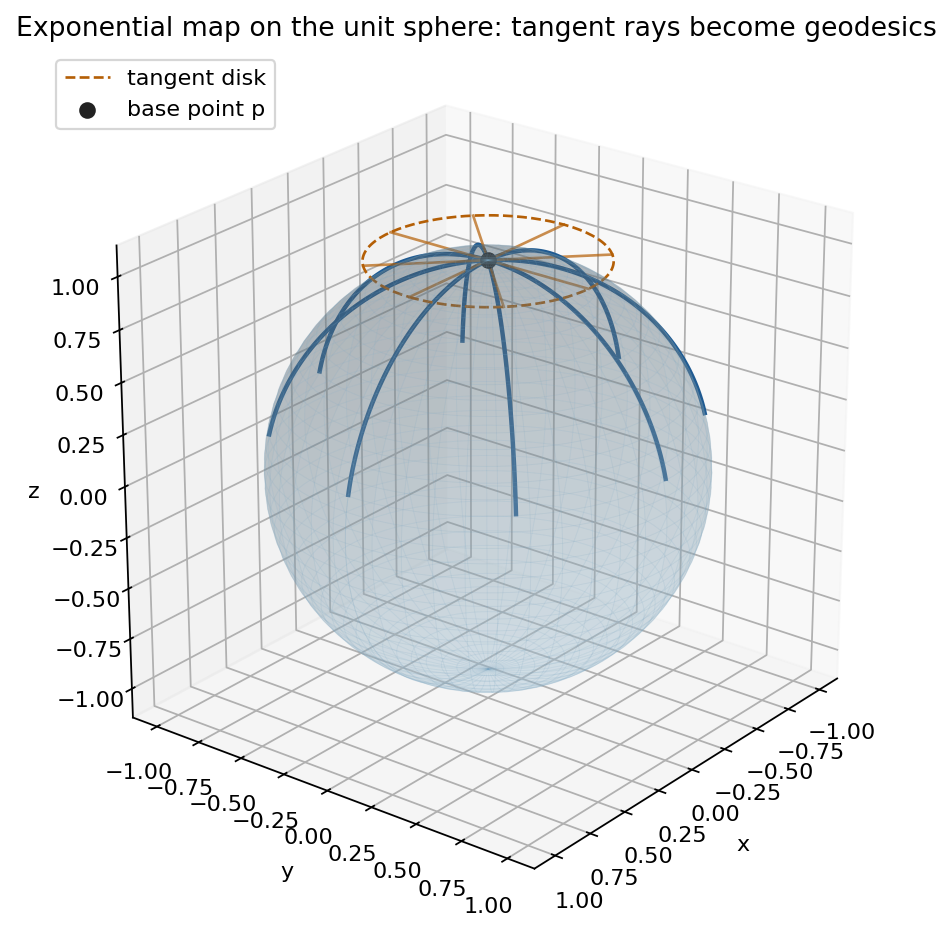

In [7]:
p_north = np.array([0.0, 0.0, 1.0])

def sphere_exp(v2: np.ndarray) -> np.ndarray:
    v3 = np.array([float(v2[0]), float(v2[1]), 0.0])
    r = np.linalg.norm(v3)
    if r < 1e-14:
        return p_north.copy()
    return math.cos(r) * p_north + (math.sin(r) / r) * v3

phi = np.linspace(0.0, 2.0 * math.pi, 90)
theta = np.linspace(0.0, math.pi, 45)
Phi, Theta = np.meshgrid(phi, theta)
Xs = np.sin(Theta) * np.cos(Phi)
Ys = np.sin(Theta) * np.sin(Phi)
Zs = np.cos(Theta)

fig = plt.figure(figsize=(8.8, 7.0))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xs, Ys, Zs, color="#b7d7ea", alpha=0.25, linewidth=0, shade=True)
ax.plot_wireframe(Xs, Ys, Zs, color="#7aa6c2", alpha=0.16, linewidth=0.4)

angles = np.linspace(0, 2 * math.pi, 9)[:-1]
radii = np.linspace(0.0, 1.35, 80)
for angle in angles:
    curve = np.array([sphere_exp(np.array([r * math.cos(angle), r * math.sin(angle)])) for r in radii])
    ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], color="#1f5a91", linewidth=2.0)
    tangent_line = np.array([[r * math.cos(angle), r * math.sin(angle), 1.0] for r in np.linspace(0, 0.55, 10)])
    ax.plot(tangent_line[:, 0], tangent_line[:, 1], tangent_line[:, 2], color="#b45f06", alpha=0.7, linewidth=1.2)

circle = np.array([[0.55 * math.cos(a), 0.55 * math.sin(a), 1.0] for a in np.linspace(0, 2 * math.pi, 160)])
ax.plot(circle[:, 0], circle[:, 1], circle[:, 2], color="#b45f06", linestyle="--", linewidth=1.2, label="tangent disk")
ax.scatter([0], [0], [1], color="#222222", s=42, label="base point p")
ax.set_title("Exponential map on the unit sphere: tangent rays become geodesics")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=24, azim=38)
ax.legend(loc="upper left")
exp_figure = record(save_matplotlib(fig, FIGURES / "sphere_exponential_geodesic_fan.png"))
plt.close(fig)

sample_vectors = [np.array([0.2, 0.1]), np.array([0.7, -0.15]), np.array([-0.3, 0.85])]
exp_points = np.array([sphere_exp(vec) for vec in sample_vectors])
norm_error = float(np.max(np.abs(np.linalg.norm(exp_points, axis=1) - 1.0)))
v0 = np.array([0.8, 0.25])
eps = 1e-6
initial_velocity = (sphere_exp(eps * v0) - p_north) / eps
initial_error = float(np.linalg.norm(initial_velocity - np.array([v0[0], v0[1], 0.0])))
exp_report = record(save_json({
    "max_unit_sphere_norm_error": norm_error,
    "initial_velocity_error": initial_error,
    "normal_coordinate_warning": "sphere exponential stops being one-to-one at the antipode; the diagram stays inside a short normal radius",
}, CHECKS / "sphere_exponential_checks.json"))
chapter_checks["sphere_exp_lands_on_sphere"] = bool(norm_error < 1e-12)
chapter_checks["sphere_exp_initial_velocity_matches_tangent_vector"] = bool(initial_error < 1e-6)
print(json.dumps({"figure": rel(exp_figure), "checks": rel(exp_report), "norm_error": norm_error, "initial_velocity_error": initial_error}, indent=2))
display_artifact(exp_figure)


### Connection Coefficients, Parallel Transport, and Cartan Equations

The exponential fan shows what geodesics do, but the chapter also develops the machinery that produces them: Christoffel symbols, covariant derivatives, parallel translation, torsion, and curvature forms. The unit sphere metric in coordinates `(theta, phi)` is a compact test case:

`g = dtheta^2 + sin(theta)^2 dphi^2`.

The code below computes the Levi-Civita Christoffel symbols from the metric, integrates the parallel-transport equation around a latitude, and checks Cartan's first and second structural equations in an orthonormal coframe. It is not a proof of the general theorem; it is a reproducible witness for the coordinate and moving-frame formulas in §§4-8.


{
  "figure": "artifacts/chapter-01-elementary-differential-geometry/figures/parallel_transport_connection_lab.png",
  "table": "artifacts/chapter-01-elementary-differential-geometry/tables/parallel_transport_connection_lab.csv",
  "checks": "artifacts/chapter-01-elementary-differential-geometry/checks/cartan_structural_equations_checks.json",
  "norm_drift": 1.0724754417879012e-12
}


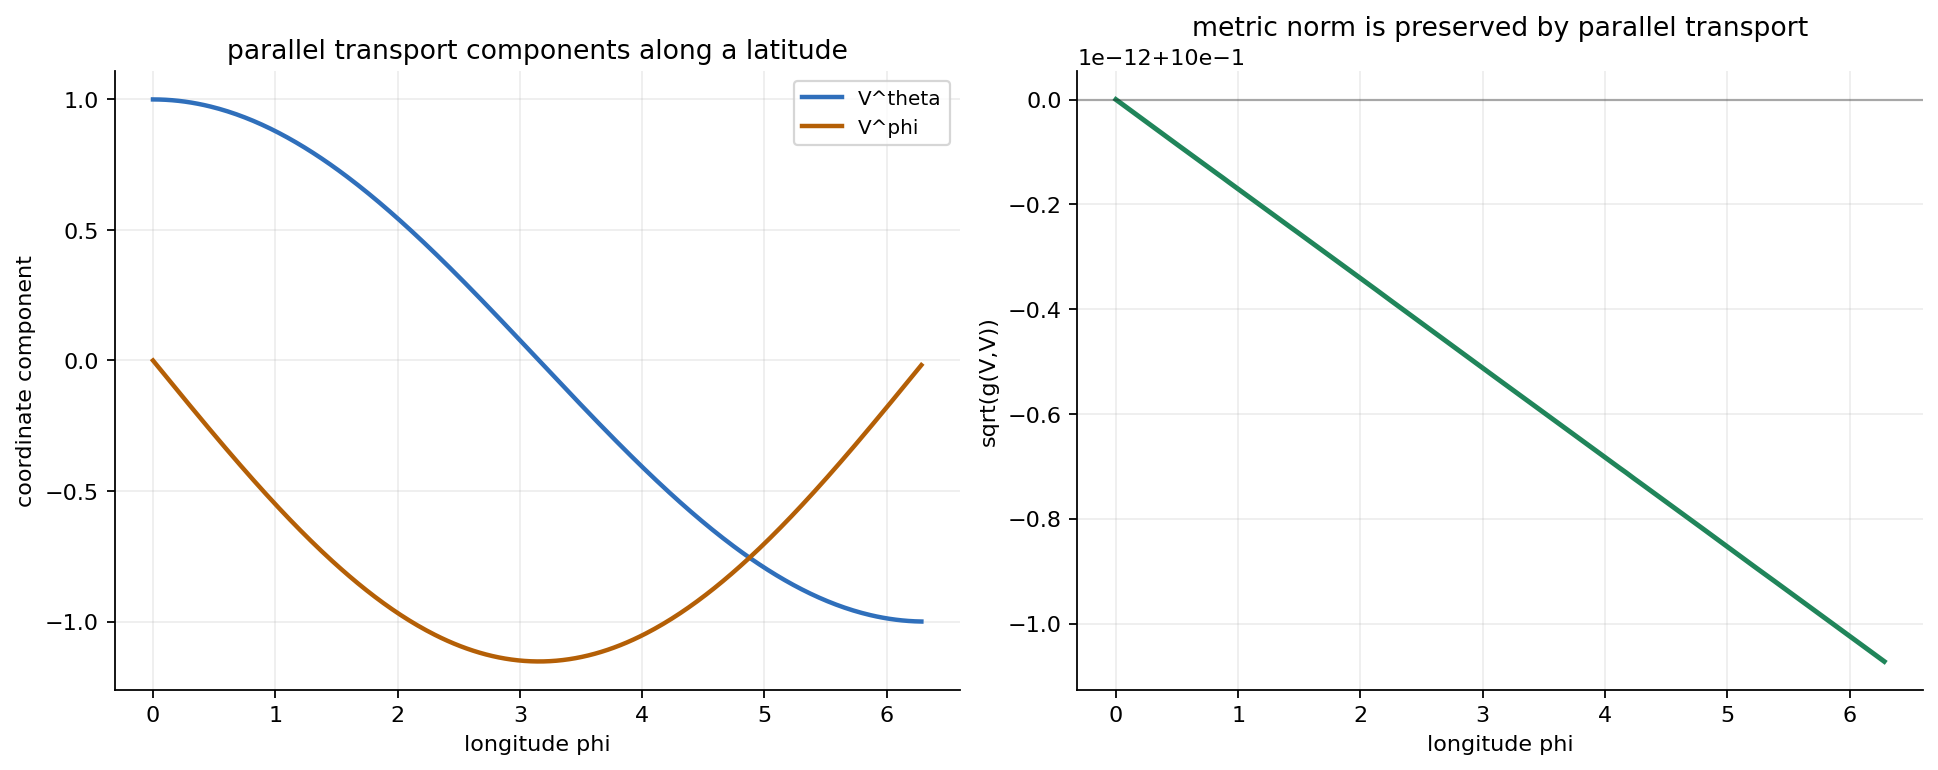

In [8]:
theta_sym, phi_sym = sp.symbols("theta phi", positive=True)
coords_sphere = [theta_sym, phi_sym]
metric = sp.Matrix([[1, 0], [0, sp.sin(theta_sym) ** 2]])
metric_inv = sp.simplify(metric.inv())

Gamma = {}
for upper in range(2):
    for lower1 in range(2):
        for lower2 in range(2):
            expr = sp.Rational(0)
            for ell in range(2):
                expr += metric_inv[upper, ell] * (
                    sp.diff(metric[ell, lower2], coords_sphere[lower1])
                    + sp.diff(metric[ell, lower1], coords_sphere[lower2])
                    - sp.diff(metric[lower1, lower2], coords_sphere[ell])
                )
            expr = sp.simplify(expr / 2)
            if expr != 0:
                Gamma[(upper, lower1, lower2)] = expr

expected_gamma = {
    (0, 1, 1): -sp.sin(theta_sym) * sp.cos(theta_sym),
    (1, 0, 1): sp.cot(theta_sym),
    (1, 1, 0): sp.cot(theta_sym),
}
christoffel_match = all(sp.simplify(Gamma.get(key, 0) - value) == 0 for key, value in expected_gamma.items())

theta0 = 1.05
sin_theta0 = math.sin(theta0)
cos_theta0 = math.cos(theta0)
cot_theta0 = cos_theta0 / sin_theta0

def transport_rhs(_phi: float, vector: np.ndarray) -> np.ndarray:
    v_theta, v_phi = vector
    return np.array([sin_theta0 * cos_theta0 * v_phi, -cot_theta0 * v_theta], dtype=float)

def rk4_step(phi_value: float, vector: np.ndarray, step: float) -> np.ndarray:
    k1 = transport_rhs(phi_value, vector)
    k2 = transport_rhs(phi_value + step / 2, vector + step * k1 / 2)
    k3 = transport_rhs(phi_value + step / 2, vector + step * k2 / 2)
    k4 = transport_rhs(phi_value + step, vector + step * k3)
    return vector + step * (k1 + 2 * k2 + 2 * k3 + k4) / 6

phi_values = np.linspace(0, 2 * math.pi, 361)
transported = np.zeros((len(phi_values), 2))
transported[0] = np.array([1.0, 0.0])
for idx in range(1, len(phi_values)):
    h = float(phi_values[idx] - phi_values[idx - 1])
    transported[idx] = rk4_step(float(phi_values[idx - 1]), transported[idx - 1], h)

transport_norm = np.sqrt(transported[:, 0] ** 2 + (sin_theta0**2) * transported[:, 1] ** 2)
norm_drift = float(np.max(np.abs(transport_norm - transport_norm[0])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), constrained_layout=True)
axes[0].plot(phi_values, transported[:, 0], color="#2f6fbb", linewidth=2.0, label="V^theta")
axes[0].plot(phi_values, transported[:, 1], color="#b45f06", linewidth=2.0, label="V^phi")
axes[0].set_title("parallel transport components along a latitude")
axes[0].set_xlabel("longitude phi")
axes[0].set_ylabel("coordinate component")
axes[0].legend(fontsize=9)
axes[1].plot(phi_values, transport_norm, color="#20855a", linewidth=2.2)
axes[1].axhline(transport_norm[0], color="#222222", alpha=0.35, linewidth=1.0)
axes[1].set_title("metric norm is preserved by parallel transport")
axes[1].set_xlabel("longitude phi")
axes[1].set_ylabel("sqrt(g(V,V))")
connection_figure = record(save_matplotlib(fig, FIGURES / "parallel_transport_connection_lab.png"))
plt.close(fig)

transport_rows = []
for idx in np.linspace(0, len(phi_values) - 1, 25, dtype=int):
    transport_rows.append({
        "phi": float(phi_values[idx]),
        "V_theta": float(transported[idx, 0]),
        "V_phi": float(transported[idx, 1]),
        "metric_norm": float(transport_norm[idx]),
    })
transport_table = record(save_csv(transport_rows, TABLES / "parallel_transport_connection_lab.csv"))

# Orthonormal coframe e1=dtheta, e2=sin(theta)dphi and connection form omega12=-cos(theta)dphi.
# A 1-form is represented by (dtheta coefficient, dphi coefficient); a 2-form by its dtheta wedge dphi coefficient.
def d_one_form(form: tuple[sp.Expr, sp.Expr]) -> sp.Expr:
    return sp.simplify(sp.diff(form[1], theta_sym) - sp.diff(form[0], phi_sym))

def wedge_forms(form_a: tuple[sp.Expr, sp.Expr], form_b: tuple[sp.Expr, sp.Expr]) -> sp.Expr:
    return sp.simplify(form_a[0] * form_b[1] - form_a[1] * form_b[0])

e1 = (sp.Integer(1), sp.Integer(0))
e2 = (sp.Integer(0), sp.sin(theta_sym))
omega12 = (sp.Integer(0), -sp.cos(theta_sym))
omega21 = (sp.Integer(0), sp.cos(theta_sym))
torsion1 = sp.simplify(d_one_form(e1) + wedge_forms(omega12, e2))
torsion2 = sp.simplify(d_one_form(e2) + wedge_forms(omega21, e1))
curvature12 = sp.simplify(d_one_form(omega12))
coframe_area = wedge_forms(e1, e2)
sectional_curvature_coeff = sp.simplify(curvature12 / coframe_area)

connection_report = record(save_json({
    "metric": "dtheta^2 + sin(theta)^2 dphi^2",
    "nonzero_christoffel_symbols": {str(key): str(value) for key, value in Gamma.items()},
    "parallel_transport_norm_drift": norm_drift,
    "cartan_first_torsion_residuals": [str(torsion1), str(torsion2)],
    "curvature_form_omega12_coefficient": str(curvature12),
    "coframe_area_coefficient": str(coframe_area),
    "sectional_curvature_coefficient": str(sectional_curvature_coeff),
    "checks": {
        "christoffel_expected_terms_match": bool(christoffel_match),
        "parallel_transport_preserves_metric_norm": bool(norm_drift < 1e-6),
        "cartan_first_structural_equation_torsion_zero": bool(torsion1 == 0 and torsion2 == 0),
        "cartan_second_structural_equation_gives_unit_curvature": bool(sp.simplify(sectional_curvature_coeff - 1) == 0),
    },
}, CHECKS / "cartan_structural_equations_checks.json"))
chapter_checks["christoffel_expected_terms_match"] = bool(christoffel_match)
chapter_checks["parallel_transport_preserves_metric_norm"] = bool(norm_drift < 1e-6)
chapter_checks["cartan_first_structural_equation_torsion_zero"] = bool(torsion1 == 0 and torsion2 == 0)
chapter_checks["cartan_second_structural_equation_gives_unit_curvature"] = bool(sp.simplify(sectional_curvature_coeff - 1) == 0)
print(json.dumps({"figure": rel(connection_figure), "table": rel(transport_table), "checks": rel(connection_report), "norm_drift": norm_drift}, indent=2))
display_artifact(connection_figure)


## 5. Structural Equations, Riemannian Curvature, and Isometry Invariants

The moving-frame viewpoint records coframes and connection forms; its structural equations say that torsion and curvature are the two obstructions detected by differentiating those forms. In a Riemannian manifold the Levi-Civita connection removes torsion, so curvature becomes the central local invariant.

Sectional curvature can be read from a two-plane. For constant-curvature surfaces, the area of a geodesic disk of radius `r` has the expansion `pi r^2 - (K pi / 12) r^4 + higher order terms`. Positive curvature makes small disks have less area than Euclidean disks; negative curvature makes them have more. The same sign appears in the radial Jacobi factor `S_K(r) / r`, which measures how nearby geodesics separate under the exponential map.


{
  "figure": "artifacts/chapter-01-elementary-differential-geometry/figures/curvature_area_and_jacobi_factors.png",
  "table": "artifacts/chapter-01-elementary-differential-geometry/tables/curvature_area_and_jacobi_factors.csv"
}


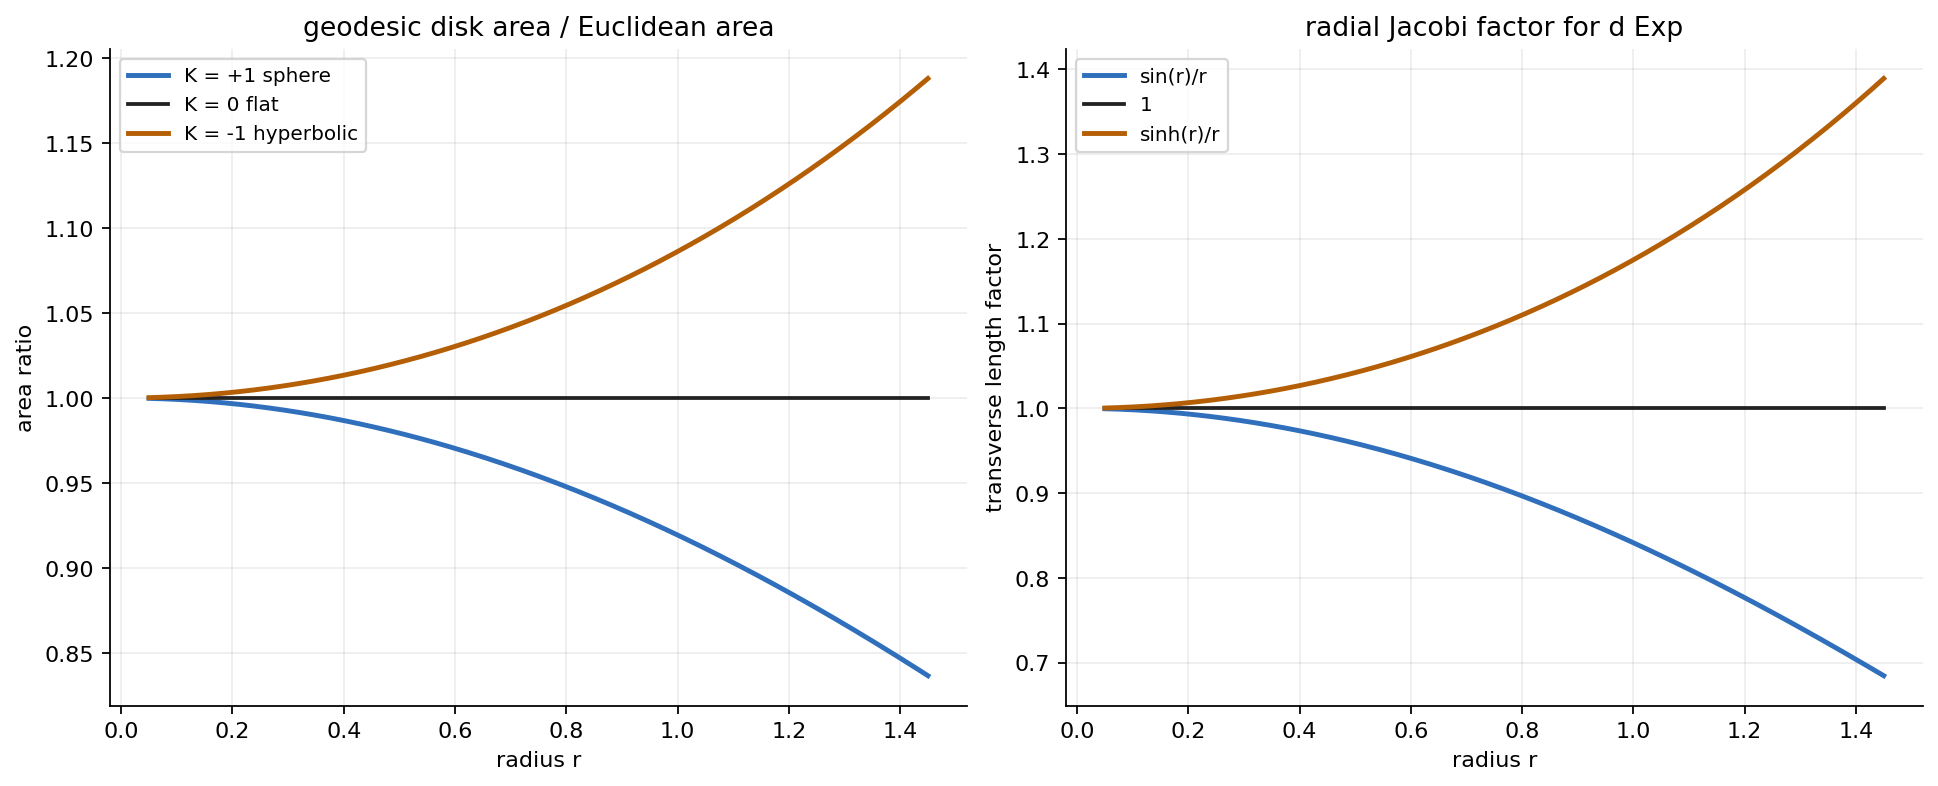

In [9]:
r = np.linspace(0.05, 1.45, 260)
area_flat = math.pi * r**2
area_sphere = 2 * math.pi * (1 - np.cos(r))
area_hyperbolic = 2 * math.pi * (np.cosh(r) - 1)
curv_est_sphere = 12 * (area_flat - area_sphere) / (math.pi * r**4)
curv_est_hyperbolic = 12 * (area_flat - area_hyperbolic) / (math.pi * r**4)

jac_sphere = np.sin(r) / r
jac_flat = np.ones_like(r)
jac_hyperbolic = np.sinh(r) / r

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
ax0, ax1 = axes
ax0.plot(r, area_sphere / area_flat, color="#2f6fbb", linewidth=2.2, label="K = +1 sphere")
ax0.plot(r, area_flat / area_flat, color="#222222", linewidth=1.7, label="K = 0 flat")
ax0.plot(r, area_hyperbolic / area_flat, color="#b45f06", linewidth=2.2, label="K = -1 hyperbolic")
ax0.set_title("geodesic disk area / Euclidean area")
ax0.set_xlabel("radius r")
ax0.set_ylabel("area ratio")
ax0.legend(fontsize=9)

ax1.plot(r, jac_sphere, color="#2f6fbb", linewidth=2.2, label="sin(r)/r")
ax1.plot(r, jac_flat, color="#222222", linewidth=1.7, label="1")
ax1.plot(r, jac_hyperbolic, color="#b45f06", linewidth=2.2, label="sinh(r)/r")
ax1.set_title("radial Jacobi factor for d Exp")
ax1.set_xlabel("radius r")
ax1.set_ylabel("transverse length factor")
ax1.legend(fontsize=9)
curvature_figure = record(save_matplotlib(fig, FIGURES / "curvature_area_and_jacobi_factors.png"))
plt.close(fig)

curvature_rows = []
for idx in np.linspace(0, len(r) - 1, 18, dtype=int):
    curvature_rows.append({
        "r": float(r[idx]),
        "sphere_area_ratio": float(area_sphere[idx] / area_flat[idx]),
        "flat_area_ratio": 1.0,
        "hyperbolic_area_ratio": float(area_hyperbolic[idx] / area_flat[idx]),
        "sphere_curvature_estimate": float(curv_est_sphere[idx]),
        "hyperbolic_curvature_estimate": float(curv_est_hyperbolic[idx]),
        "sphere_jacobi_factor": float(jac_sphere[idx]),
        "hyperbolic_jacobi_factor": float(jac_hyperbolic[idx]),
    })
curvature_table = record(save_csv(curvature_rows, TABLES / "curvature_area_and_jacobi_factors.csv"))
small = r < 0.18
chapter_checks["sphere_small_disk_curvature_near_one"] = bool(abs(float(np.mean(curv_est_sphere[small])) - 1.0) < 0.02)
chapter_checks["hyperbolic_small_disk_curvature_near_minus_one"] = bool(abs(float(np.mean(curv_est_hyperbolic[small])) + 1.0) < 0.02)
chapter_checks["negative_curvature_expands_transverse_lengths"] = bool(np.all(jac_hyperbolic >= jac_flat - 1e-12))
chapter_checks["positive_curvature_contracts_short_transverse_lengths"] = bool(np.all(jac_sphere <= jac_flat + 1e-12))
print(json.dumps({"figure": rel(curvature_figure), "table": rel(curvature_table)}, indent=2))
display_artifact(curvature_figure)


## 6. Negative Curvature and the Exponential Map

The negative-curvature section proves that, under its hypotheses, the exponential map does not shrink tangent vectors transverse to the radial direction. That single comparison feeds several consequences: triangles have angle sum at most pi, complete simply connected negatively curved spaces have no conjugate points, the exponential map becomes a global diffeomorphism, compact isometry groups have a common fixed point, and totally geodesic submanifolds admit a normal decomposition.

The lab below sweeps constant curvature `K`. For a surface of constant curvature, the transverse factor of the exponential map is `S_K(r)/r`. Negative `K` pushes the factor above one; positive `K` pushes it below one before the first conjugate radius. This is a compact computational model for the chapter's comparison argument.


{
  "figure": "artifacts/chapter-01-elementary-differential-geometry/figures/curvature_sign_lab.png",
  "table": "artifacts/chapter-01-elementary-differential-geometry/tables/curvature_sign_lab.csv",
  "probe_radius": 1.0
}


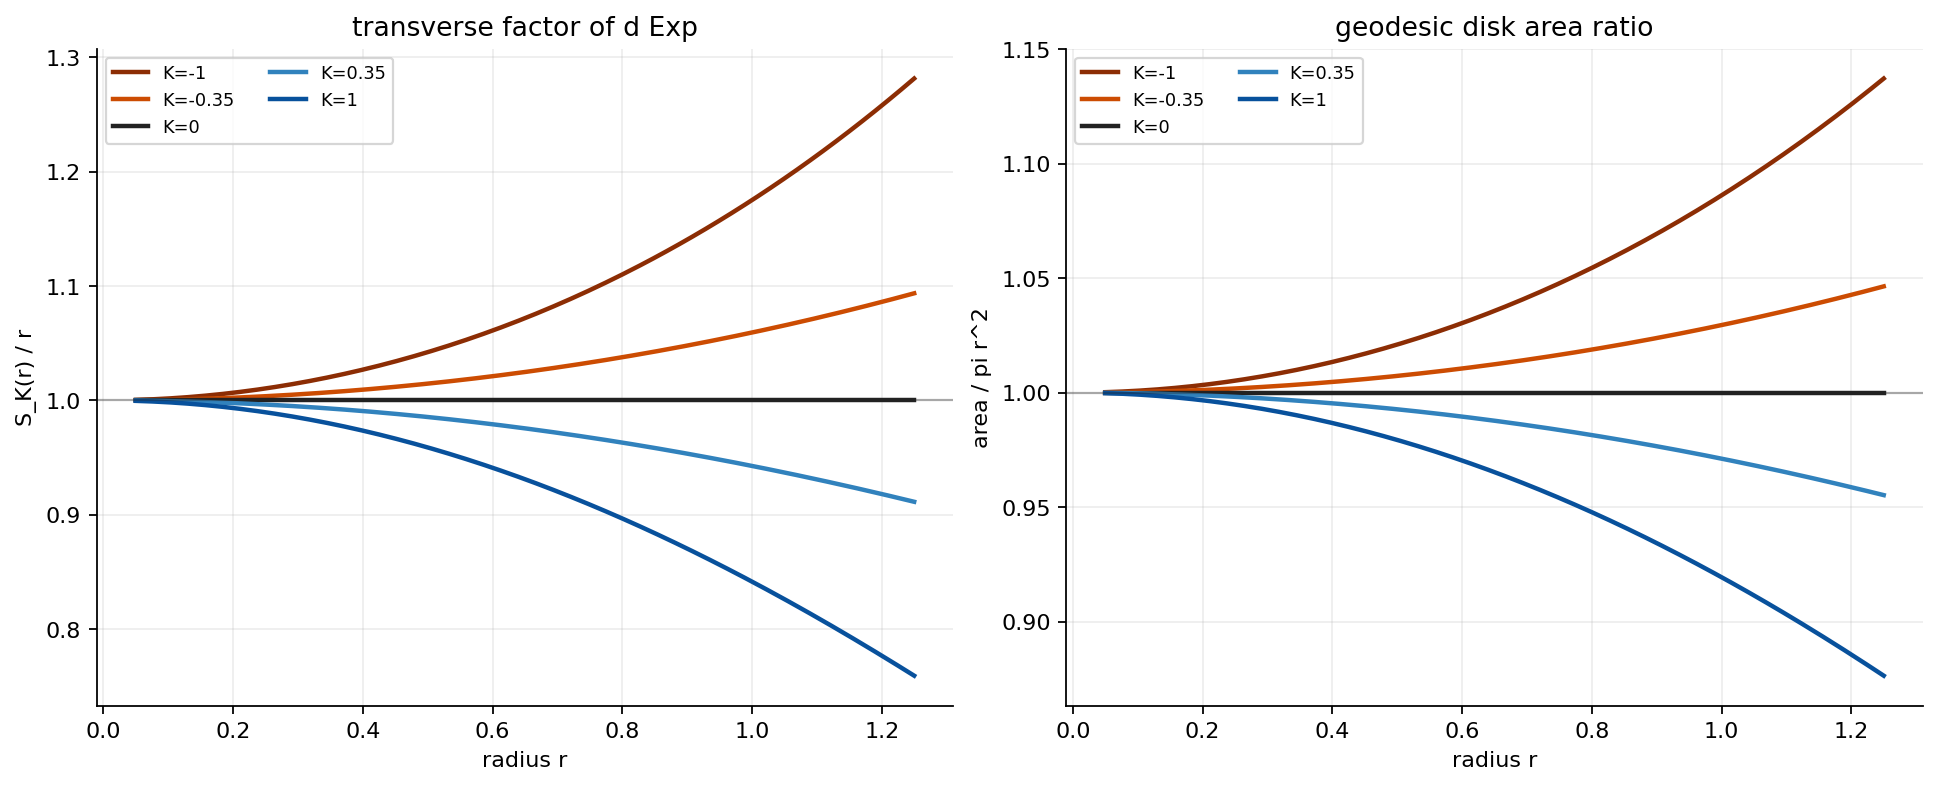

In [10]:
def S_K(k: float, radius: np.ndarray) -> np.ndarray:
    radius = np.asarray(radius, dtype=float)
    if abs(k) < 1e-14:
        return radius.copy()
    if k > 0:
        root = math.sqrt(k)
        return np.sin(root * radius) / root
    root = math.sqrt(-k)
    return np.sinh(root * radius) / root

def area_K(k: float, radius: np.ndarray) -> np.ndarray:
    radius = np.asarray(radius, dtype=float)
    if abs(k) < 1e-14:
        return math.pi * radius**2
    if k > 0:
        root = math.sqrt(k)
        return 2 * math.pi * (1 - np.cos(root * radius)) / k
    root = math.sqrt(-k)
    return 2 * math.pi * (np.cosh(root * radius) - 1) / (-k)

r_lab = np.linspace(0.05, 1.25, 180)
curvatures = [-1.0, -0.35, 0.0, 0.35, 1.0]
colors = ["#8c2d04", "#cc4c02", "#222222", "#3182bd", "#08519c"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for k, color in zip(curvatures, colors):
    factor = S_K(k, r_lab) / r_lab
    axes[0].plot(r_lab, factor, color=color, linewidth=2.0, label=f"K={k:g}")
    axes[1].plot(r_lab, area_K(k, r_lab) / (math.pi * r_lab**2), color=color, linewidth=2.0, label=f"K={k:g}")
axes[0].axhline(1.0, color="#222222", alpha=0.35, linewidth=1.0)
axes[0].set_title("transverse factor of d Exp")
axes[0].set_xlabel("radius r")
axes[0].set_ylabel("S_K(r) / r")
axes[0].legend(fontsize=8, ncol=2)
axes[1].axhline(1.0, color="#222222", alpha=0.35, linewidth=1.0)
axes[1].set_title("geodesic disk area ratio")
axes[1].set_xlabel("radius r")
axes[1].set_ylabel("area / pi r^2")
axes[1].legend(fontsize=8, ncol=2)
lab_figure = record(save_matplotlib(fig, FIGURES / "curvature_sign_lab.png"))
plt.close(fig)

radius_probe = 1.0
lab_rows = []
for k in curvatures:
    lab_rows.append({
        "curvature_K": float(k),
        "jacobi_factor_at_r1": float(S_K(k, np.array([radius_probe]))[0] / radius_probe),
        "area_ratio_at_r1": float(area_K(k, np.array([radius_probe]))[0] / (math.pi * radius_probe**2)),
    })
lab_table = record(save_csv(lab_rows, TABLES / "curvature_sign_lab.csv"))
by_k = {row["curvature_K"]: row for row in lab_rows}
chapter_checks["negative_curvature_factor_above_flat_at_r1"] = bool(by_k[-1.0]["jacobi_factor_at_r1"] > by_k[0.0]["jacobi_factor_at_r1"])
chapter_checks["positive_curvature_factor_below_flat_at_r1"] = bool(by_k[1.0]["jacobi_factor_at_r1"] < by_k[0.0]["jacobi_factor_at_r1"])
chapter_checks["negative_curvature_area_above_flat_at_r1"] = bool(by_k[-1.0]["area_ratio_at_r1"] > by_k[0.0]["area_ratio_at_r1"])
print(json.dumps({"figure": rel(lab_figure), "table": rel(lab_table), "probe_radius": radius_probe}, indent=2))
display_artifact(lab_figure)


## 7. Totally Geodesic Submanifolds

A submanifold can have its own intrinsic geodesics without being totally geodesic in the ambient space. The stronger condition says that every ambient geodesic initially tangent to the submanifold remains inside it. Equivalently, ambient parallel transport along curves in the submanifold keeps tangent vectors tangent. In negative curvature, closed totally geodesic submanifolds interact cleanly with normal geodesics, giving a disjoint normal decomposition of the ambient space.

On the sphere, the equator is a totally geodesic submanifold: its acceleration is purely normal to the sphere, so the tangent part of the ambient acceleration vanishes. A latitude circle is intrinsically a curve, but it is not an ambient geodesic; its tangent acceleration residual is nonzero.


{
  "figure": "artifacts/chapter-01-elementary-differential-geometry/figures/totally_geodesic_equator_vs_latitude.png",
  "table": "artifacts/chapter-01-elementary-differential-geometry/tables/totally_geodesic_residuals.csv",
  "equator_max_residual": 2.482534153247273e-16,
  "latitude_mean_residual": 0.5039032598602688
}


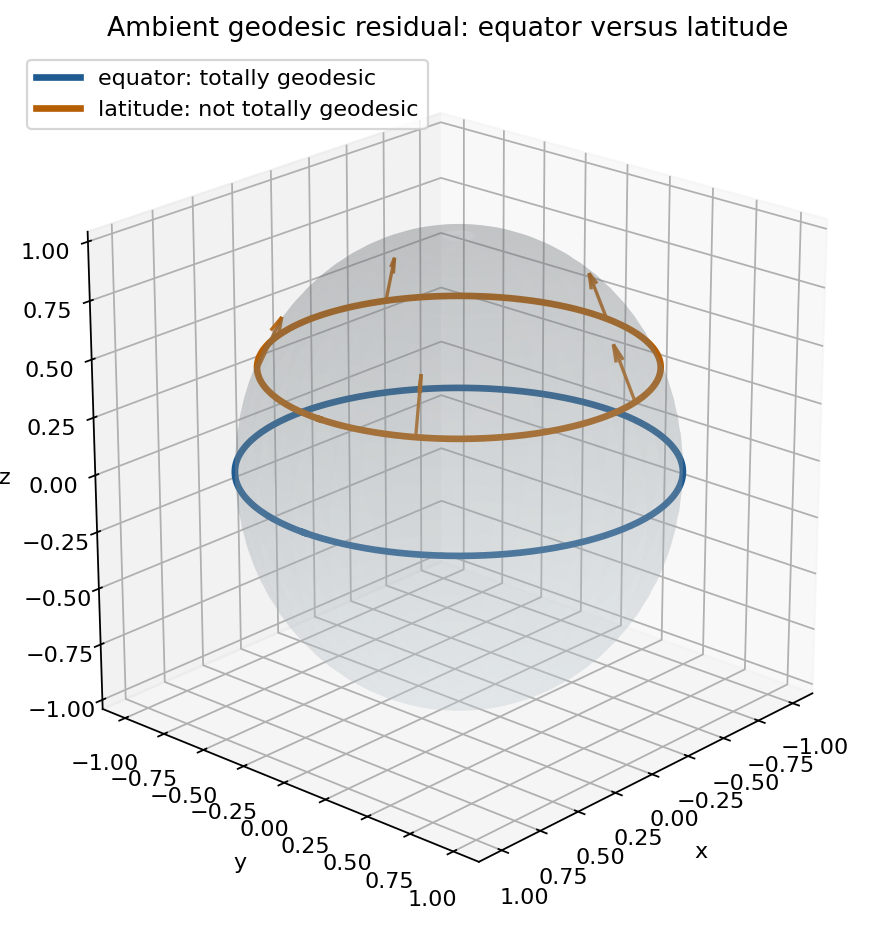

In [11]:
def sphere_tangent_residual_for_latitude(z0: float, samples: int = 240) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rho = math.sqrt(max(1.0 - z0**2, 0.0))
    t = np.linspace(0, 2 * math.pi, samples)
    gamma = np.column_stack([rho * np.cos(t), rho * np.sin(t), np.full_like(t, z0)])
    if rho < 1e-14:
        accel = np.zeros_like(gamma)
    else:
        accel = np.column_stack([-(np.cos(t) / rho), -(np.sin(t) / rho), np.zeros_like(t)])
    normal_projection = np.sum(accel * gamma, axis=1)[:, None] * gamma
    tangent_residual = accel - normal_projection
    return gamma, accel, tangent_residual

equator, _, equator_residual = sphere_tangent_residual_for_latitude(0.0)
latitude, _, latitude_residual = sphere_tangent_residual_for_latitude(0.45)

fig = plt.figure(figsize=(8.8, 7.0))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xs, Ys, Zs, color="#d9e7ef", alpha=0.20, linewidth=0, shade=True)
ax.plot(equator[:, 0], equator[:, 1], equator[:, 2], color="#1f5a91", linewidth=3.0, label="equator: totally geodesic")
ax.plot(latitude[:, 0], latitude[:, 1], latitude[:, 2], color="#b45f06", linewidth=3.0, label="latitude: not totally geodesic")
for idx in np.linspace(20, 210, 5, dtype=int):
    start = latitude[idx]
    vec = latitude_residual[idx]
    ax.quiver(start[0], start[1], start[2], vec[0], vec[1], vec[2], color="#b45f06", length=0.25, normalize=True, alpha=0.9)
ax.set_title("Ambient geodesic residual: equator versus latitude")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=22, azim=42)
ax.legend(loc="upper left")
geodesic_figure = record(save_matplotlib(fig, FIGURES / "totally_geodesic_equator_vs_latitude.png"))
plt.close(fig)

equator_max = float(np.max(np.linalg.norm(equator_residual, axis=1)))
latitude_mean = float(np.mean(np.linalg.norm(latitude_residual, axis=1)))
geodesic_rows = [
    {"curve": "equator", "residual_statistic": "max", "tangent_acceleration_residual": equator_max, "interpretation": "ambient geodesic"},
    {"curve": "latitude_z_0_45", "residual_statistic": "mean", "tangent_acceleration_residual": latitude_mean, "interpretation": "not ambient geodesic"},
]
geodesic_table = record(save_csv(geodesic_rows, TABLES / "totally_geodesic_residuals.csv"))
chapter_checks["equator_tangent_residual_zero"] = bool(equator_max < 1e-12)
chapter_checks["latitude_tangent_residual_nonzero"] = bool(latitude_mean > 0.05)
print(json.dumps({"figure": rel(geodesic_figure), "table": rel(geodesic_table), "equator_max_residual": equator_max, "latitude_mean_residual": latitude_mean}, indent=2))
display_artifact(geodesic_figure)


## Applied Lab: What Survives a Change of Curvature Sign?

The chapter repeatedly asks which conclusions are local, which need completeness, and which depend on the sign of curvature. The lab functions above let you change a single scalar `K` and re-run the two quantities that drive many of the comparison statements: the transverse factor of the exponential map and the geodesic disk area ratio.

Try replacing the `curvatures` list with a denser sweep, or change `radius_probe`. The stable facts should remain clear: negative curvature expands transverse separation and disk area relative to flat space; positive curvature contracts them locally and eventually creates conjugate behavior outside the short-radius range. This is a computational doorway to the hyperbolic disk exercises, while the coverage ledger marks other exercise themes that need separate proof work beyond this compact lab.


## Final Sanity and Artifact Check

The checks are intentionally tied to the chapter's content rather than to figure count. They verify that the partition really sums to one, symbolic exterior calculus identities hold, the map is regular on the model square, the sphere exponential map lands on the sphere with the right initial velocity, curvature sign changes the expected measurements, and the totally geodesic example separates equator from latitude.


In [12]:
final_sanity = {
    "chapter": "Chapter I. Elementary Differential Geometry",
    "source_span": "printed pages 2-97, approximately PDF pages 29-124",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks,
    "coverage_note": "Every source section 1-15 and exercise group A-G has an entry in chapter_01_coverage_map.csv; core geometric mechanisms are represented by executable visuals or symbolic checks.",
}

failed = [name for name, value in chapter_checks.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")

final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)


{
  "final_sanity": "artifacts/chapter-01-elementary-differential-geometry/checks/final_sanity.json",
  "boolean_checks": 23,
  "failed": []
}


`final_sanity.json`

## Takeaways

Chapter I builds the working grammar for the rest of the book. A differentiable manifold is controlled locally by charts but used globally through smooth functions, partitions of unity, vector fields, and forms. A smooth map is understood through its differential, and stable rank is what turns level sets and images into clean submanifolds. An affine connection adds a rule for differentiating vector fields along vector fields, so parallelism, geodesics, torsion, and curvature become intrinsic rather than coordinate artifacts.

The Riemannian part narrows the connection to the Levi-Civita connection and turns curvature into a metric measurement. Normal coordinates and the exponential map explain why short geodesics minimize distance locally; sectional curvature explains how small disks, Jacobi fields, and geodesic triangles deviate from Euclidean behavior. Negative curvature has especially rigid consequences: exponential maps expand transverse directions, complete simply connected examples have no conjugate points, compact isometry groups acquire fixed points, and totally geodesic submanifolds interact with normal geodesics in a highly organized way.

The appendix and exercise groups supply the technical tools that make the main constructions legal: paracompactness and shrinking covers, constant-rank normal forms, projectable vector fields, Lie derivatives, curvature by holonomy, surface connections, and the hyperbolic disk. This notebook gives executable witnesses for the recurring mechanisms, and the coverage ledger separates those from further proof exercises that should be worked by hand.
